Check mask flip

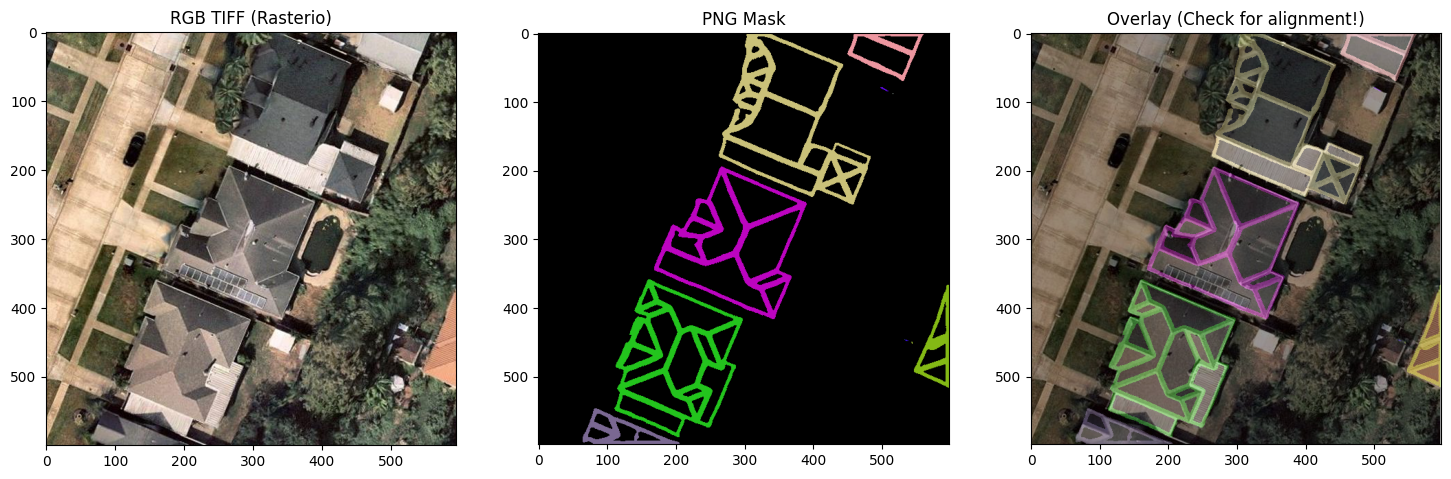

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def verify_hybrid_alignment(tif_path, png_path):
    # 1. Load the TIFF RGB using Rasterio
    with rasterio.open(tif_path) as src:
        # Read first 3 bands, transpose from (C, H, W) to (H, W, C)
        img = src.read([1, 2, 3])
        img = np.transpose(img, (1, 2, 0))
        
        # Normalize for display (Handles 16-bit or 8-bit)
        img_min, img_max = img.min(), img.max()
        img_vis = (img - img_min) / (img_max - img_min)

    # 2. Load the PNG Mask using PIL
    mask = np.array(Image.open(png_path))

    # 3. Visualization
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    ax[0].imshow(img_vis)
    ax[0].set_title("RGB TIFF (Rasterio)")
    
    ax[1].imshow(mask, cmap='gray')
    ax[1].set_title("PNG Mask")
    
    # Overlay - this tells you if the Y-flip exists
    ax[2].imshow(img_vis)
    ax[2].imshow(mask, alpha=0.4, cmap='spring')
    ax[2].set_title("Overlay (Check for alignment!)")
    
    plt.show()

verify_hybrid_alignment(r'data\train\It_01\images\29.955597_-90.003119_nearmap_rgb.tif', r'data\train\It_01\masks\29.955597_-90.003119_nearmap_rgb_connected.png')

Mask flip check validated.

In [2]:
import torch
import torch.nn as nn
# Bias is false coz its handled in batchnorm 2D padding =1 to maintain input dims = output dims
# inplace=true for no extra tensor allocation for the relu
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            # First Conv Layer
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            
            # Second Conv Layer
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [3]:
# Maxpool reduces dims by 1/2 like 1024->512
class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Down, self).__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

In [4]:
import torch.nn.functional as F

class Up(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Up, self).__init__()
        # Argument,Role in ConvTranspose2d
        # stride,Determines the upscaling ratio.
        # kernel_size,Determines the overlap between upscaled pixels.
        # padding,Decreases the output size (trims the edges).
        # output_padding,Increases the output size by a precise amount to match skip-connections.
        # in_channels here is the number of channels from the previous decoder layer
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        # DoubleConv takes (Upsampled Channels + Skip Connection Channels)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1: incoming feature map from the previous decoder layer (to be upsampled)
        # x2: skip connection feature map from the encoder
        x1 = self.up(x1)
        
        # In case the input size is not a perfect power of 2, we pad x1 to match x2
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        
        # Concatenate along the channel dimension (dim=1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

In [5]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes

        # Encoder (Downsampling)
        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 1024) # The Bottleneck

        # Decoder (Upsampling + Skip Connections)
        # Note: 'Up' block handles the channel concatenation internally
        self.up1 = Up(1024, 512)
        self.up2 = Up(512, 256)
        self.up3 = Up(256, 128)
        self.up4 = Up(128, 64)
        
        # Final Output Layer (1x1 Convolution)
        self.outc = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder Path
        x1 = self.inc(x)     # High-res features for skip connection
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)  # Bottom of the "U"

        # Decoder Path (Passing the skip connection as the second argument)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        logits = self.outc(x)
        return logits

In [6]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        # Flatten label and prediction tensors
        inputs = torch.sigmoid(inputs)       
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        # Dice Calculation
        intersection = (inputs * targets).sum()                            
        dice_loss = 1 - (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)  
        
        # Standard BCE
        BCE = nn.functional.binary_cross_entropy(inputs, targets, reduction='mean')
        
        return BCE + dice_loss

In [7]:
def get_iou(outputs, masks):
    # Threshold predictions at 0.5 to get binary mask
    outputs = (torch.sigmoid(outputs) > 0.5).float()
    
    intersection = (outputs * masks).sum()
    union = outputs.sum() + masks.sum() - intersection
    
    if union == 0:
        return 1.0 # Perfect score if both are empty
    return (intersection / union).item()

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_iou = 0
    
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        
        # Forward
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_iou += get_iou(outputs, masks)
        
    return total_loss / len(loader), total_iou / len(loader)

In [9]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define the augmentation pipeline
train_transform = A.Compose([
    A.PadIfNeeded(min_height=608, min_width=608, border_mode=0, value=0, mask_value=0),
    A.HorizontalFlip(p=0.5),
    ToTensorV2(),
])



c:\Users\adity\miniconda3\envs\pytorch-gpu-env\lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [10]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Define the magic padding formula
train_transform = A.Compose([
    # This forces all images to be exactly 608x608
    A.PadIfNeeded(min_height=608, min_width=608, border_mode=0, value=0, mask_value=0),
    A.HorizontalFlip(p=0.5),
    ToTensorV2(),
])

In [11]:
from torch.utils.data import Dataset
class RoofDataset_S(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = train_transform
        
        # 1. Get all base IDs from image folder (stripping .tif)
        self.image_files = {f for f in os.listdir(image_dir) if f.endswith('.tif')}
        
        # 2. Match them to masks by adding the suffix
        self.valid_pairs = []
        for img_f in self.image_files:
            base_id = os.path.splitext(img_f)[0] # e.g., 29.955597_-90.003119_nearmap_rgb
            mask_f = f"{base_id}_connected.png"
            
            if os.path.exists(os.path.join(mask_dir, mask_f)):
                self.valid_pairs.append((img_f, mask_f))
        
        self.valid_pairs.sort() # Ensure consistent order
        print(f"Successfully paired {len(self.valid_pairs)} images with their '_connected' masks.")

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, index):
        img_filename, mask_filename = self.valid_pairs[index]
        
        # 1. Load Image
        with rasterio.open(os.path.join(self.image_dir, img_filename)) as src:
            img = src.read([1, 2, 3]) 
            img = np.transpose(img, (1, 2, 0)).astype(np.float32)
            img /= 255.0 if np.max(img) > 1.0 else 1.0

        # 2. Load Mask
        mask = np.array(Image.open(os.path.join(self.mask_dir, mask_filename)).convert("L"), dtype=np.float32)
        mask = (mask > 0).astype(np.float32)

        # --- THE HARD RESET: FORCE EXACT PIXEL MATCH ---
        # If the image is 600x597, we force the mask to be 600x597
        if img.shape[:2] != mask.shape[:2]:
            mask_pil = Image.fromarray(mask)
            # PIL uses (width, height) order for resize
            mask = np.array(mask_pil.resize((img.shape[1], img.shape[0]), resample=Image.NEAREST))

        # 3. Apply Transform
        # Now Albumentations will see identical shapes and won't complain
        augmented = self.transform(image=img, mask=mask)
        img, mask = augmented['image'], augmented['mask']
        
        if len(mask.shape) == 2:
            mask = mask.unsqueeze(0)

        return img, mask

Successfully paired 99 images with their '_connected' masks.


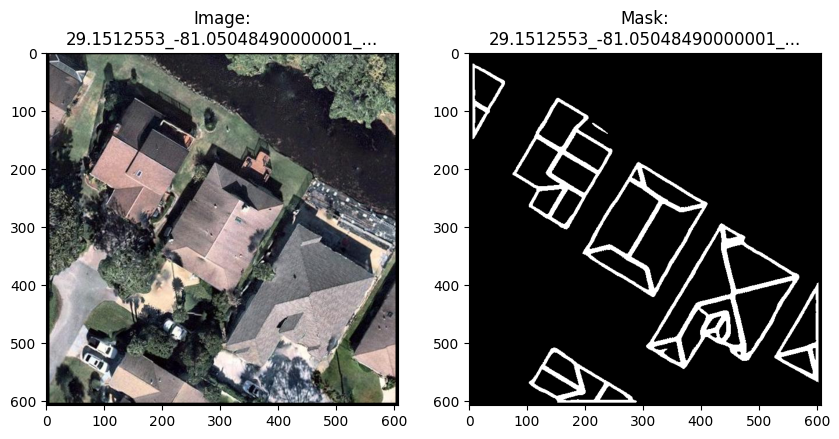

Confirmed Match: 29.1512553_-81.05048490000001_nearmap_rgb.tif <---> 29.1512553_-81.05048490000001_nearmap_rgb_connected.png


In [12]:
import os
# Instantiate with your nearmap paths
test_ds = RoofDataset_S(r"data\train\It_01\images", r"data\train\It_01\masks", transform=train_transform)

# Show the first pair
img, msk = test_ds[0]
img_name, msk_name = test_ds.valid_pairs[0]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img.permute(1, 2, 0))
plt.title(f"Image:\n{img_name[:30]}...")

plt.subplot(1, 2, 2)
plt.imshow(msk.squeeze(), cmap='gray')
plt.title(f"Mask:\n{msk_name[:30]}...")
plt.show()

print(f"Confirmed Match: {img_name} <---> {msk_name}")

In [13]:
import os
from torch.utils.data import DataLoader
# Use the validated Dataset class from our previous steps
train_dataset = RoofDataset_S(
    image_dir=r"data\train\It_01\images", 
    mask_dir=r"data\train\It_01\masks",
    transform=None
)

# Define the loader that was "missing"
train_loader = DataLoader(
    train_dataset, 
    batch_size=2, 
    shuffle=True, 
    num_workers=0
)

print(f"Librarian ready! Found {len(train_dataset)} images.")

Successfully paired 99 images with their '_connected' masks.
Librarian ready! Found 99 images.


In [14]:
import rasterio
# 1. Reset Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 2. Re-initialize Model correctly
model = UNet(n_channels=3, n_classes=1) 
model.to(device) # <--- This is where ._apply lives. It moves the model.

# 3. Pull Data
try:
    images, masks = next(iter(train_loader))
    
    # Move Tensors to device
    images = images.to(device)
    masks = masks.to(device)
    
    print(f"Input Shape: {images.shape}")

    # 4. Forward Pass
    model.eval() # Set to eval mode for the cold run
    with torch.no_grad():
        outputs = model(images)
    
    print(f"Forward Pass Success! Output shape: {outputs.shape}")

except Exception as e:
    print(f"Error encountered: {e}")

Using device: cuda
Input Shape: torch.Size([2, 3, 608, 608])
Forward Pass Success! Output shape: torch.Size([2, 1, 608, 608])


In [15]:
from tqdm.auto import tqdm
import time

def train_model(model, train_loader, optimizer, criterion, device, num_epochs=25):
    history = {'loss': [], 'iou': []}
    model.to(device)
    
    print(f"Starting Training on {device}...")
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        epoch_iou = 0
        
        # --- PROGRESS BAR SETUP ---
        # desc: Label on the left | leave=True: Keeps the bar after finishing
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), 
                    desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
        
        for batch_idx, (images, masks) in pbar:
            images, masks = images.to(device), masks.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # Backward pass
            loss.backward()
            optimizer.step()

            # Metrics
            epoch_loss += loss.item()
            current_iou = get_iou(outputs, masks) # Ensure your get_iou function is defined
            epoch_iou += current_iou

            # --- UPDATE PROGRESS BAR ---
            # This shows real-time stats next to the ETA
            pbar.set_postfix({
                'loss': f"{loss.item():.4f}",
                'iou': f"{current_iou:.4f}"
            })

        # Epoch Results
        avg_loss = epoch_loss / len(train_loader)
        avg_iou = epoch_iou / len(train_loader)
        
        history['loss'].append(avg_loss)
        history['iou'].append(avg_iou)

        # Save checkpoint
        if (epoch + 1) % 5 == 0:
            torch.save(model.state_dict(), f"roof_model_epoch_{epoch+1}.pth")

    total_time = time.time() - start_time
    print(f"\nTraining Complete in {total_time/60:.2f} minutes!")
    return history

# --- EXECUTION ---
# Ensure these variables are already defined from our previous steps
# model = UNet(...)
# optimizer = Adam(...)
# criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = DiceBCELoss() # Call it with () to create the object
train_history = train_model(model, train_loader, optimizer, criterion, device, num_epochs=25)

Starting Training on cuda...


Epoch 1/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 3/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 4/25:   0%|          | 0/50 [00:00<?, ?it/s]

...

Epoch 22/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 23/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 24/25:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 25/25:   0%|          | 0/50 [00:00<?, ?it/s]


Training Complete in 37.36 minutes!


In [16]:
# Create a descriptive filename
model_save_path = "roof_unet_v1_final.pth"

# Save only the weights
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved safely to {model_save_path}")

Model weights saved safely to roof_unet_v1_final.pth


In [17]:
checkpoint = {
    'epoch': 20,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': train_history['loss'][-1],
}

torch.save(checkpoint, "roof_unet_checkpoint.pth")

Model Loading

In [18]:
# # 1. Create a fresh model shell
# loaded_model = UNet(n_channels=3, n_classes=1)

# # 2. Load the weights into that shell
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# loaded_model.load_state_dict(torch.load("roof_unet_v1_final.pth", map_location=device))

# # 3. Set to evaluation mode
# loaded_model.to(device)
# loaded_model.eval()

# print("Model successfully reloaded and ready for prediction!")